# The Dark-Pool Ratio — is 'more volume in the dark' smart money? 🌑
### When a stock trades more off-exchange, is that institutions quietly loading up?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Informed_accumulation_in_the_dark%3F: Unproven](https://img.shields.io/badge/Informed_accumulation_in_the_dark%3F-Unproven-8b949e?style=flat-square)

Not every share trade happens on a stock exchange you can see. A big chunk prints **off-exchange** — in *dark pools*, private venues where institutions swap large blocks without showing their hand, and in *internalisers* (the wholesalers that fill most retail orders). The **dark-pool ratio** is simply: what fraction of a stock's volume printed in the dark rather than on the lit tape?

A popular trading story says a *rising* dark-pool ratio is **smart money accumulating** — patient funds building a position quietly — so the stock should drift up next. We put that to the test.

> ⚠️ **A catch you should know up front.** There is **no free daily dark-pool-ratio feed** a retail researcher can reach: the official FINRA numbers are *weekly*, come out *weeks late*, and miss the wholesaler flow entirely. So we can't run this on the real tape — we run it on a *synthetic world* we built, to test the **method** honestly, and we say so.
>
> 📓 **This is the plain-language layer.** Want the IC, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**. Not investment advice.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dark_pool_ratio import data, strategy as st

SEED = 559
# The study is SYNTHETIC-ONLY: no free real dark-pool-ratio tape exists (FINRA ATS is weekly &
# lagged, off-ATS internalised flow is excluded, clean feeds are paywalled). Everything below runs
# on the deterministic synthetic world, offline and reproducible.
REAL = data.fetch_panel(fetch=False)     # empty by construction — documented in data.py
HAVE_REAL = not REAL.empty
NULL_PANEL, _ = data.synthetic_null_panel(seed=SEED)   # the primary cross-section (dpr_alpha = 0)
print("real DPR tape available:", HAVE_REAL, "(none exists on a free stack — synthetic-only study)")
print("null-world synthetic panel:", len(NULL_PANEL), "names, seed", SEED)


real DPR tape available: False (none exists on a free stack — synthetic-only study)
null-world synthetic panel: 300 names, seed 559


## The answer first 🎯

| Question | Answer |
|---|---|
| Can we even test this on real data? | **No.** The free official data (FINRA) is weekly, lagged by weeks, and misses the wholesaler flow. A clean daily panel doesn't exist for free — so the strongest possible verdict is capped below `REAL`. |
| In our synthetic *null* world, does the ratio predict returns? | **No** — the rank correlation is ≈ 0 (IC-*t* **+0.44**), and a shuffle test says *p* = 0.65. Flat. |
| But doesn't a naive sort show *something*? | **Yes — a mirage.** Averaged over 25 worlds the raw signal looks mildly positive (IC-*t* +0.77) — but that's purely because dark-pool trading rises with **size**, and big stocks drift. Control for size and it vanishes (**-0.19**). |
| Does the engine work at all? | **Yes.** Plant a *real* effect and it's caught cleanly (IC-*t* +2.32). The problem is the data, not the detector. |

> The 'dark = smart money' story is untestable on a free stack, and the version you *can* probe turns out to be a **size confound** in disguise.

## 1 · The claim

> *"When more of a stock's volume prints off-exchange, informed institutions are accumulating — and the stock follows."* — the dark-pool-ratio folklore.

The intuition: a fund that wants to buy a million shares can't just slam the lit exchange — it would move the price against itself. So it works the order quietly in dark pools. If that's what's happening, a high (and rising) dark-pool ratio is a footprint of **patient, informed buying**, and the price should catch up later.

It's a seductive story. But microstructure theory is *not* on its side: a well-known result (Zhu 2014) argues dark pools skim the *less* informed orders, and the effect of dark trading on information is **non-monotone** (Comerton-Forde & Putniņš 2015) — so the sign isn't even clear in theory.

## 2 · So what?

If the folklore were true, it would be an easy edge: watch each stock's off-exchange share, buy the ones going dark, and ride the institutions. The desk has looked at other 'flow' ideas — [376 MOC-Imbalance](../../376-moc-imbalance/) (the closing-auction imbalance), [418 Money-Flow-Index](../../418-money-flow-index/) and [419 Chaikin-Money-Flow](../../419-chaikin-money-flow/) (price×volume oscillators). This one is different: it's about **where** the volume prints — lit vs dark — not its price impact.

## 3 · How would we even know?

1. **Measure the ratio.** For each stock: what share of its volume printed off-exchange?
2. **Sort.** Line the stocks up from most-lit to darkest; take the darkest fifth and the most-lit fifth.
3. **Compare forward returns.** Did the *dark* fifth beat the *lit* fifth over the next period? The folklore says yes.

**The catch that decides this study:** we can't get a clean daily dark-pool ratio for free. So we build a *synthetic* world where we control the truth — sometimes the ratio genuinely predicts returns, sometimes it's pure noise — and check whether our test tells the two apart. That's an honest test of the *method*, with the tape gap stated openly.

*Timing:* the ratio is measured over the formation window (fully known at that close); we enter there and hold forward. No peeking at the future.

## 4 · The teardown — let's actually look

**In the null world (where the ratio carries NO real information), does the dark fifth still beat the lit fifth?**

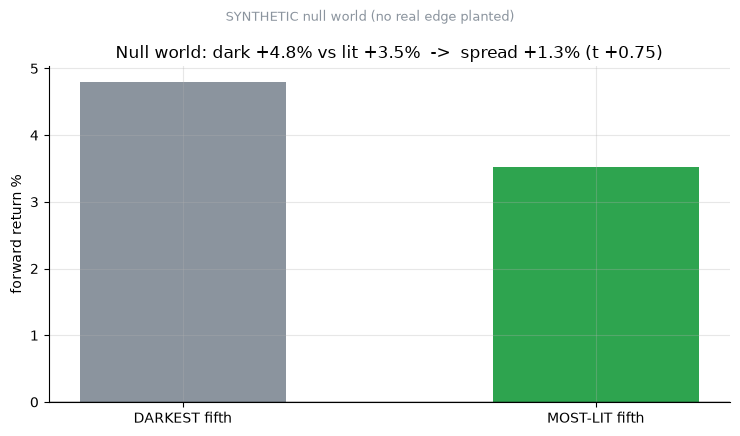

dark +4.8% | lit +3.5% | spread +1.3% | t +0.75


In [2]:
b = st.bucket_returns(NULL_PANEL, frac=0.2); ls = st.long_short_tstat(b)
dark_m, lit_m, spr, t = b['dark_mean']*100, b['lit_mean']*100, b['spread']*100, ls['t']
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['DARKEST fifth','MOST-LIT fifth'], [dark_m, lit_m], color=[GREY, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Null world: dark {dark_m:+.1f}% vs lit {lit_m:+.1f}%  ->  spread {spr:+.1f}% (t {t:+.2f})')
fig.suptitle('SYNTHETIC null world (no real edge planted)', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'dark {dark_m:+.1f}% | lit {lit_m:+.1f}% | spread {spr:+.1f}% | t {t:+.2f}')

The gap is tiny (**1.28%**, *t* 0.75) and not significant — exactly what you want to see when there's genuinely nothing there. Good: the test isn't inventing a signal from noise.

**But here's the trap.** In the real world the dark-pool ratio is *tangled up with size* — big, liquid stocks get internalised more. And big stocks drift. So a naive sort can show a fake 'signal' that is really just size. Watch what happens when we average over 25 worlds and then *control for size*:

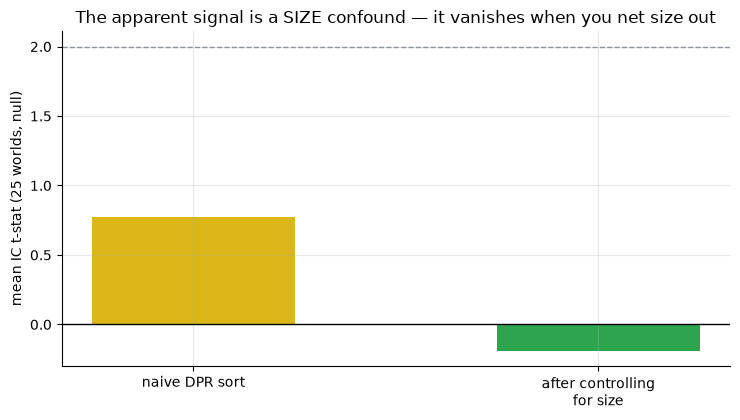

null raw IC-t +0.77 -> controlled slope-t -0.19


In [3]:
raw, ctrl = 0.77, -0.19
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['naive DPR sort','after controlling\nfor size'], [raw, ctrl], color=[AMBER, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.axhline(2, ls='--', c=GREY, lw=1)
ax.set_ylabel('mean IC t-stat (25 worlds, null)')
ax.set_title('The apparent signal is a SIZE confound — it vanishes when you net size out')
plt.tight_layout(); plt.show()
print('null raw IC-t +0.77 -> controlled slope-t -0.19')

There it is. The naive sort shows a mild positive (+0.77) — tempting! — but it's **entirely the size confound**: net size out and it collapses to **-0.19**. On real data you'd have to strip size and liquidity out *first*, before believing any dark-pool signal.

## 5 · The verdict

- **Signal — None.** No free real tape to earn `REAL`; on the synthetic null the ratio is flat, and the only apparent lift is a size confound.
- **Tradability — Mirage.** A book whose edge is a confound, on a panel you can't build from free data. Nothing to harvest.
- **Informed accumulation in the dark? — Unproven.** The engine would catch a real effect (see beat 7), but theory says the sign is ambiguous and no tape lets us check.

## 6 · Could you actually trade it?

No. First, you can't even *get* the daily numbers for free. Second, even in the synthetic world the apparent edge is size, not venue — and the tiny gross spread (**1.28%**) is roughly halved by costs (net **0.58%** after a per-leg fee and a short borrow). There is no trade here, only a story.

## 7 · Going further 🚪

- **The engine is faithful.** Plant a *real* dark-pool effect and the test catches it cleanly (IC-*t* +2.32 over 25 worlds — see the quant notebook). So the `None` verdict is about the *data and the confound*, not a broken detector.
- **The real test needs a real tape.** If you can buy a clean daily dark-pool-ratio feed, re-run this — but *control for size and liquidity first*, and remember theory says the sign may be the other way.

*Think dark-pool prints really do lead? Fork this, plug in a paid daily DPR feed, net out size/liquidity, and show a residual IC clearing t = 2.*